In [62]:
import sys

print(sys.executable)

c:\Users\ASUS\anaconda3\python.exe


In [63]:
import sys

!{sys.executable} -m pip install shap

In [64]:
import shap

print(shap.__version__)

0.52.0


In [65]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv(
    "../data/processed/cleaned_telco.csv"
)

In [67]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

X = df_encoded.drop(
    "Churn",
    axis=1
)

y = df_encoded["Churn"]

In [68]:
X = X.drop(
    columns=[
        "AvgRevenue",
        "TenureGroup_1-2 Years",
        "TenureGroup_2-4 Years",
        "TenureGroup_4-6 Years"
    ],
    errors="ignore"
)

In [69]:
print(X.shape)

(7043, 30)


In [70]:
lr = joblib.load(
    "../models/best_model.pkl"
)

In [71]:
explainer = shap.Explainer(
    lr,
    X
)

Background dataset has 7043 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7043 when initializing the masker.


In [72]:
shap_values = explainer(
    X
)

In [74]:
print(X.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [75]:
print(X.dtypes.value_counts())

bool       26
int64       2
float64     2
Name: count, dtype: int64


In [76]:
X.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [77]:
X = X.astype(float)

In [78]:
print(X.dtypes.unique())

[dtype('float64')]


In [79]:
import shap

explainer = shap.Explainer(
    lr,
    X
)

shap_values = explainer(X)

Background dataset has 7043 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7043 when initializing the masker.


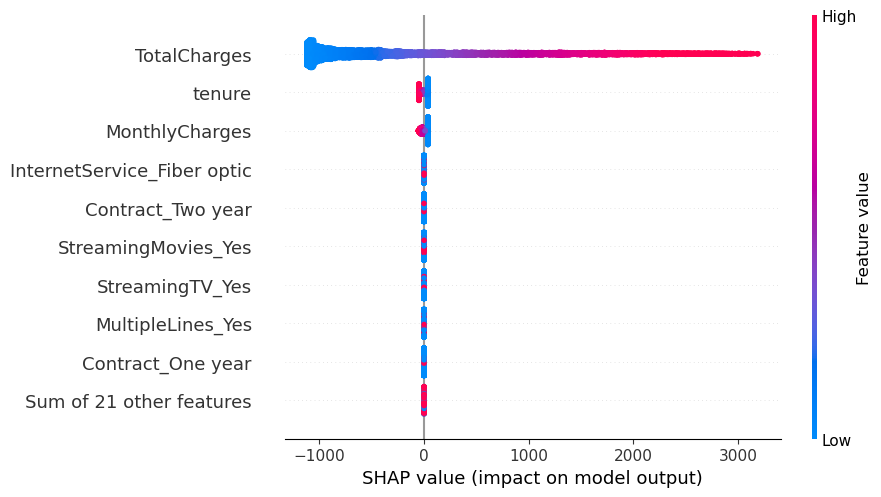

In [80]:
shap.plots.beeswarm(shap_values)